<a href="https://colab.research.google.com/github/dakshini01/ProdFusion/blob/main/codes/SimpleLinearRegressionModeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 2. UPLOAD DATASET
# =========================

from google.colab import files
uploaded = files.upload()

Saving garments_worker_productivity.csv to garments_worker_productivity.csv


In [14]:
# =========================
# 3. LOAD DATASET
# =========================

df = pd.read_csv("garments_worker_productivity.csv")

# =========================
# 4. CLEAN TEXT COLUMNS
# =========================

df["department"] = df["department"].str.strip()
df["day"] = df["day"].str.strip()
df["quarter"] = df["quarter"].str.strip()

# =========================
# 5. CONVERT DATE
# =========================

df["date"] = pd.to_datetime(df["date"])

# =========================
# 6. HANDLE MISSING WIP
# =========================

df["wip_missing"] = df["wip"].isnull().astype(int)
df["wip"] = df["wip"].fillna(0)

# =========================
# 7. SELECT REQUIRED COLUMNS
# =========================

df = df[[
    "date",
    "actual_productivity",
    "targeted_productivity",
    "smv",
    "wip",
    "over_time",
    "incentive",
    "idle_time",
    "idle_men",
    "no_of_style_change",
    "no_of_workers",
    "team",
    "department",
    "day",
    "wip_missing"
]]

# =========================
# 8. SORT BY DATE
# =========================

df = df.sort_values("date").reset_index(drop=True)

# =========================
# 9. ONE-HOT ENCODE CATEGORICAL VARIABLES
# =========================

df = pd.get_dummies(df, columns=["department", "day"], drop_first=True)

# Convert True/False to 0/1
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(int)

# =========================
# 10. TIME-BASED TRAIN TEST SPLIT
# =========================

unique_dates = sorted(df["date"].unique())

split_index = int(0.8 * len(unique_dates))
cutoff_date = unique_dates[split_index]

train = df[df["date"] < cutoff_date].copy()
test = df[df["date"] >= cutoff_date].copy()

# =========================
# 11. SEPARATE FEATURES AND TARGET
# =========================

X_train = train.drop(columns=["actual_productivity", "date"])
y_train = train["actual_productivity"]

X_test = test.drop(columns=["actual_productivity", "date"])
y_test = test["actual_productivity"]

# =========================
# 12. SCALE NUMERICAL FEATURES
# =========================

numeric_cols = [
    "targeted_productivity",
    "smv",
    "wip",
    "over_time",
    "incentive",
    "idle_time",
    "idle_men",
    "no_of_style_change",
    "no_of_workers",
    "team"
]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# =========================
# 13. CHECK FINAL DATA
# =========================

print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

print(X_train.head())

Missing values in X_train: 0
Missing values in X_test: 0
   targeted_productivity       smv       wip  over_time  incentive  idle_time  \
0               0.681091  0.990614  0.222467   0.661526   2.246832  -0.063455   
1              -0.333872 -1.006870 -0.437404  -0.940960  -0.843812  -0.063455   
2              -0.841354  0.766453  0.075366   0.695621  -0.843812  -0.063455   
3               0.681091 -1.120312 -0.437404  -1.077342  -0.843812  -0.063455   
4               0.173609 -1.025928 -0.437404  -0.736387  -0.843812  -0.063455   

   idle_men  no_of_style_change  no_of_workers      team  wip_missing  \
0 -0.111435           -0.316424       1.076731  0.452061            0   
1 -0.111435           -0.316424      -1.039348  1.323232            1   
2 -0.111435           -0.316424       1.121754 -0.709501            0   
3 -0.111435           -0.316424      -1.219439  0.161670            1   
4 -0.111435           -0.316424      -0.769210 -0.709501            1   

   department_swe

In [15]:
# =========================
# 14. TRAIN LINEAR REGRESSION MODEL
# =========================

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [17]:
# =========================
# 15. MAKE PREDICTIONS
# =========================

y_pred = linear_model.predict(X_test)

# =========================
# 16. EVALUATE MODEL
# =========================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results
MAE: 0.2912172970883944
RMSE: 1.1791177893492106
R2 Score: -52.10781111408757


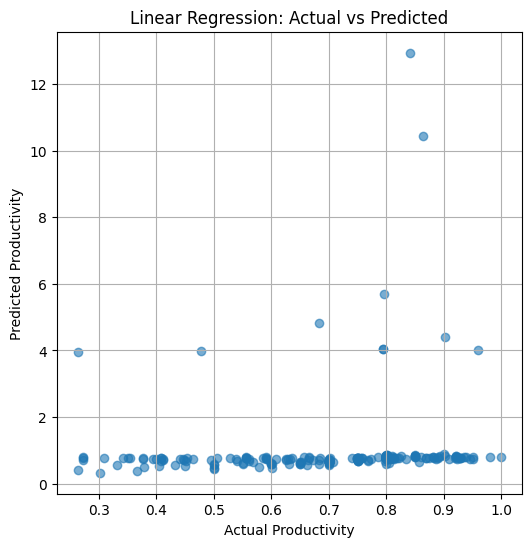

In [18]:
# =========================
# 17. ACTUAL VS PREDICTED GRAPH
# =========================

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

In [19]:
# =========================
# 18. FEATURE COEFFICIENTS
# =========================

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_model.coef_
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

print(coefficients)

                  Feature  Coefficient
4               incentive     0.107172
10            wip_missing     0.092048
8           no_of_workers     0.052590
0   targeted_productivity     0.042986
12           day_Saturday     0.018106
15            day_Tuesday     0.010303
5               idle_time     0.007348
7      no_of_style_change     0.000957
2                     wip    -0.001406
14           day_Thursday    -0.004379
13             day_Sunday    -0.005874
16          day_Wednesday    -0.009006
3               over_time    -0.012214
6                idle_men    -0.017991
9                    team    -0.019195
1                     smv    -0.049012
11      department_sweing    -0.092048


In [20]:
# =========================
# 19. TOP POSITIVE AND NEGATIVE FACTORS
# =========================

print("Top Positive Factors:")
print(coefficients.head(10))

print("\nTop Negative Factors:")
print(coefficients.tail(10))

Top Positive Factors:
                  Feature  Coefficient
4               incentive     0.107172
10            wip_missing     0.092048
8           no_of_workers     0.052590
0   targeted_productivity     0.042986
12           day_Saturday     0.018106
15            day_Tuesday     0.010303
5               idle_time     0.007348
7      no_of_style_change     0.000957
2                     wip    -0.001406
14           day_Thursday    -0.004379

Top Negative Factors:
               Feature  Coefficient
7   no_of_style_change     0.000957
2                  wip    -0.001406
14        day_Thursday    -0.004379
13          day_Sunday    -0.005874
16       day_Wednesday    -0.009006
3            over_time    -0.012214
6             idle_men    -0.017991
9                 team    -0.019195
1                  smv    -0.049012
11   department_sweing    -0.092048


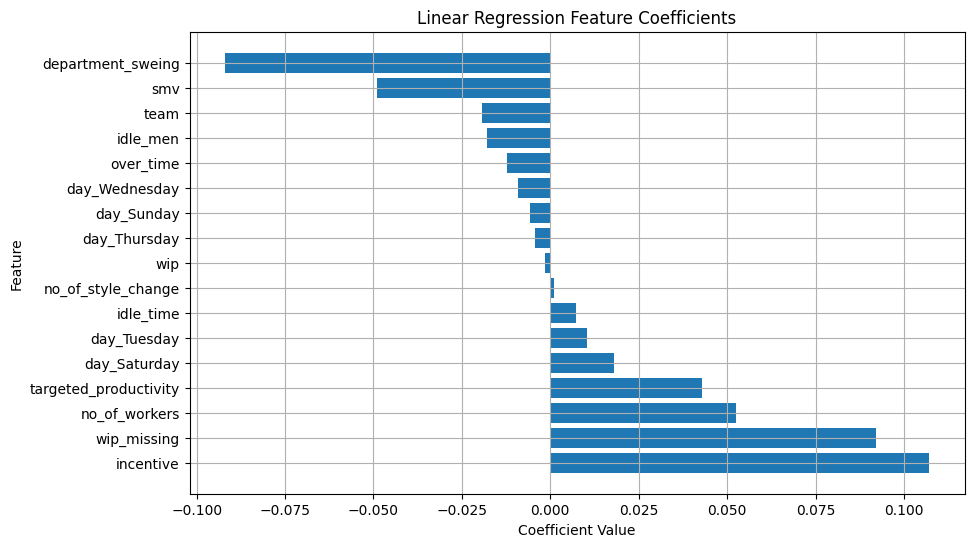

In [21]:
# =========================
# 20. COEFFICIENT BAR CHART
# =========================

plt.figure(figsize=(10,6))
plt.barh(coefficients["Feature"], coefficients["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Linear Regression Feature Coefficients")
plt.grid(True)
plt.show()

The linear regression model was used as a baseline. However, the results show a very low R² value, indicating that productivity cannot be explained using simple linear relationships. This suggests the presence of complex and non-linear interactions in the data.